# GeoLocate Demo: Successful Market Entry Location Prediction and Mapping Tool

GeoLocate Spatial AI tool designed to identify geographically favorable locations for market entry. By integrating multi-modal data from **high-resolution satellite imagery (Sentinel-2)**, **topological road infrastructure (OSM)**, and **comprehensive socioeconomic data (IBGE/RFB)**, we predict success for market entry locations across complex regional landscapes.

Key innovations include:

1. **Spatial Dependency Modeling**: Using ICAR priors to capture "market contagion" effects where success in one municipality spills over into its neighbors.
2. **Multi-Domain Integration**: Deep integration of spectral environmental indices (NDVI/NDBI) with objective economic indicators and physical road density metrics.
3. **Risk-Aware Decision Support**: Quantification of posterior uncertainty to distinguish between robust "Safe Opportunities" and volatile "High Stakes" zones.

In this notebook, we will cover the full workflow for GeoLocate, a map processing vision model to geolocate and find the best locaction for new ventures, from data preparation to model training, including:

1. Data Description and Data Processing:  
2. Example Usage and Results: 
3. Conclusion, Future Works, and Limitations: We will discuss the current state and achievements and the future steps to improve our model.

#### Want to learn more?

Check out repositories Model GitHub repo: [rtjaiany/succesful_areas](https://github.com/rtjaiany/succesful_areas)

### Table of Contents
1. [Introduction](#1-·-Introduction)
   - [Why GeoLocate?](#1-·-Introduction)
2. [Data Description & AI-Readiness](#2-·-Data-Description-&-AI-Readiness)
3. [Methodological Description](#2-·-Data-Description-&-AI-Readiness)
4. [Bayesian Modelling (Use case: São Paulo)](#3-·-Bayesian-Modelling-(first-draft-for-SP))
   - [Setup & Data Preparation](#Data-Preparation)
   - [Pre-Modeling Diagnostics](#Essential-Pre-Modeling-Diagnostics)
   - [Robust Bayesian ICAR Model](#Robust-Bayesian-ICAR-Model)
   - [Success Index and Risk Mapping](#Success-Index-and-Risk-Mapping)
5. [Scaling to Nation-wide Model](#5-·-Next-Steps-&-Scaling-the-Framework)
6. [Results](#5-·-Impact-and-Future-Directions)
7. [Validation](#5-·-Impact-and-Future-Directions)
8. [Impact and Future Directions](#5-·-Impact-and-Future-Directions)

## 1 - Introduction

Deciding the spatial location for market entry  is one of the most critical strategic decisions for firms seeking sustained growth and long-term competitive advantage. It represents a pivotal step into an uncertain environment, where firms must evaluate demand, competition, infrastructure, and regional conditions before committing significant resources. Despite its strategic importance, market entry remains highly risky. Global statistics suggest that nearly 50% of new ventures cease operations within their first five years (Shepard, 2024). Among these failures, approximately 35% occur because the product or service does not meet an actual market need (CB Insights, 2021). These figures highlight the complexity of identifying viable opportunities and underscore the importance of informed entry strategies.

Within the strategic management and entrepreneurship literature, market entry is commonly defined as a firm's strategic move into a new or existing market (Markman et al., 2019). A growing body of research emphasizes that successful entry depends not only on firm capabilities but also on external environmental conditions such as market size, institutional context, and competitive dynamics (Akhter & Robles, 2006; Schellenberg et al., 2018). Consequently, improving the ability to identify favorable conditions for market entry has become a key concern for scholars and practitioners.

However, existing market-entry frameworks often prioritize aggregate indicators such as market size, income levels, or industry growth (e.g., Conceição et al., 2021; Pennerstorfer & Yontcheva, 2021), while paying comparatively limited attention to spatial heterogeneity, the geographic variation in infrastructure, accessibility, demographics, and economic activity that shapes real market opportunities. This limitation is particularly pronounced in developing or structurally uneven regions, where economic conditions can vary dramatically across short geographic distances.

### Why GeoLocate?

In the contexts above, entrepreneurs and policymakers frequently lack robust spatial decision-support tools to reveal where business opportunities are most viable. Poor location decisions can lead to misallocation of capital, increased business failure rates, and the reinforcement of regional economic inequality. Addressing this gap requires analytical approaches that integrate multiple sources of spatial information, including socioeconomic indicators, infrastructure data, and remotely sensed environmental signals, into predictive frameworks for market success.

To address this challenge, this project **proposes a Spatial Artificial Intelligence (Spatial AI) framework based on a Bayesian hierarchical spatial model to identify geographically favorable locations for market entry**. The framework will integrate multiple sources of spatial data, including census indicators, infrastructure, and road information derived from OpenStreetMap (OSM), and remote sensing data from Sentinel-2 satellite imagery processed in Google Earth Engine (GEE). Satellite imagery provides high-resolution information on land-use patterns, urban expansion, vegetation dynamics, and built-environment characteristics, which can serve as valuable proxies for economic activity, population concentration, and accessibility, especially in regions where traditional economic statistics are incomplete, outdated, or unavailable.

By combining these heterogeneous spatial datasets, the model will estimate the probability that specific locations can support the successful establishment of new firms. The resulting framework will generate probabilistic spatial maps that rank areas according to their predicted likelihood of supporting viable market entry. Brazil will serve as the initial pilot case due to its large regional disparities. However, the methodology is designed to be generalizable to other developing economies and underserved regions within advanced countries.

## 2 - Data Description & AI-Readiness

### AI-Ready Data Standards
To ensure the model receives high-quality signals, we implemented a rigorous data pipeline:
- **Completeness**: Handling of missing values via median imputation and invalid row filtering (Binomial n > 0).
- **Structure**: Unified IBGE 7-digit coding across all four data layers.
- **Accessibility**: All raw features (OSM, Sentinel-2, IBGE) are derived from open-access repositories.

| Layer | Source | License/Standard | Key Variables |
|-------|--------|------------------|---------------|
| **Satellite** | Sentinel-2 / GEE | CC BY-SA 3.0 | NDVI, EVI, NDBI, SWIR (100m res) |
| **Roads** | OpenStreetMap | ODbL 1.0 | Road/Intersection Density ($km/km^2$) |
| **Socio-Econ** | IBGE / RFB | Open Data (BR) | HDI, GDP/capita, Avg. Salary |
| **Business** | Receita Federal | Public Domain | Active/Failed counts (Target variable) |

--- 
**FAIR Metadata**: 
- **Interoperability**: Geospatial data uses **EPSG:4674** (SIRGAS 2000) for Brazil standard.
- **Reproducibility**: Pre-modeling diagnostics (Global Moran’s I, VIF) are implemented to validate model assumptions statistically.

## 3 - Method

### Model Formulation: The BYM2 Architecture

To predict the probability of business success ($p_i$) in municipality $i$, we implement a **Bayesian Hierarchical Spatial Model** known as **BYM2** (Besag-York-Mollié 2, Riebler et al. 2016). This model is specifically designed to handle both individual municipality characteristics and the spatial dependencies among neighbors (with at least one border shared).

#### 1. The Likelihood
We treat the number of active firms ($y_i$) as a Binomial process out of the total firms ($n_i$):
$$ y_i \sim \text{Binomial}(n_i, p_i) $$

#### 2. The Linear Predictor
The success probability $p_i$ is modeled via a logit link function:
$$ \text{logit}(p_i) = \alpha + X_i \beta + \epsilon_i $$
Where:
- $\alpha$: Global intercept (baseline state-wide success rate).
- $X_i \beta$: Fixed effects (standardized impacts of Road Density, income, etc.).
- $\epsilon_i$: Combined random effect (The spatial "secret sauce").

#### 3. The Re-parameterized Spatial Component (BYM2)
Unlike standard models, BYM2 splits the error $\epsilon_i$ into structured and unstructured components using a mixing parameter $\rho$:
$$ \epsilon_i = \sigma \left( \sqrt{1-\rho} \theta_i + \sqrt{\frac{\rho}{s}} \phi_i \right) $$
Where:
- **$\sigma$ (Total Variance)**: Controls the overall strength of the random effects.
- **$\rho$ (Mixing Parameter Factor)**: This ranges from 0 to 1. If $\rho \to 1$, the variation is entirely spatial; if $\rho \to 0$, it is purely independent noise.
- **$\phi_i$ (Structured Effect)**: Follows an **Intrinsic Conditional Autoregressive (ICAR)** prior, where the value of a municipality is the average of its neighbors.
- **$\theta_i$ (Unstructured Effect)**: Standard i.i.d. Gaussian noise ($N(0,1)$).
- **$s$ (Riebler Scaling Factor)**: A constant that ensures the variance of the spatial component is approximately 1, making $\rho$ easily interpretable.

### Why this matters?
This formulation allows us to determine **exactly how much of the success rate is due to local policy/infrastructure ($\beta$) versus regional "contagion" effects ($\rho$)**.

## 4 - Use Case: São Paulo

São Paulo was selected as the pilot case due to its structural and economic centrality within Brazil and the analytical challenges it presents for spatial modeling. The state accounts for approximately 31% of national GDP and contains 645 municipalities, the largest number in the country, providing substantial intra-regional heterogeneity. With a population exceeding 44 million and a highly diversified economic structure encompassing industry, services, finance, and agribusiness, São Paulo combines large-scale economic activity with significant spatial variation in development levels.

Importantly, São Paulo represents a particularly demanding environment for spatial analysis. The state exhibits a dense municipal adjacency structure, strong metropolitan concentration around the São Paulo Metropolitan Region, and pronounced economic gradients between highly industrialized urban centers and less-developed interior municipalities. These characteristics generate complex spatial dependencies and substantial variation in market conditions across relatively short distances. Consequently, São Paulo provides a rigorous empirical setting for evaluating the performance and robustness of the proposed Spatial AI framework. Its economic weight, sectoral diversity, and high-quality data availability make it an ideal benchmark for validating the model before scaling the methodology to the national level and, ultimately, to other developing regions.

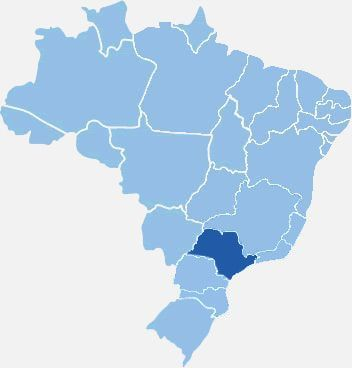


### Setup: Install Dependencies
Run this cell if you haven't installed the needed libraries yet.

In [ ]:
# %pip install pymc arviz libpysal esda spreg statsmodels scipy pytensor seaborn matplotlib numpy pandas geopandas shapely --break-system-packages

print("✅ Libraries installed successfully!")

### Performance Note
If you see a warning about `g++ not available`, the model will run slower in "Python-only" mode.
**To fix (recommended):** Run `conda install -c conda-forge m2w64-toolchain` in your terminal.

In [ ]:
# ── 1. Utilities and Environment Setup ──
import gc
import time
import datetime
import warnings
from pathlib import Path

# ── 2. Core Scientific and Geospatial Libraries ──
import numpy as np
import pandas as pd
import scipy as sp
import geopandas as gpd
from shapely import wkt

# ── 3. Visualization ──
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# ── 4. Statistical and Spatial Analysis ──
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import libpysal as lps
from esda.moran import Moran

# ── 5. Bayesian Modeling ──
import pymc as pm
import pymc.sampling.jax as pm_jax
import pytensor.tensor as pt
import arviz as az

# ── 6. Formatting & Confirmation ──
# Suppress warnings for cleaner notebook presentation
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="viridis")

print("✅ Libraries installed and loaded successfully!")

### Data Preparation

In [ ]:
DATA_PATH = Path("/home/.../final_integrated_dataset.csv") #change for the file path

# Define subset of columns for memory efficiency during initial analysis
cols_to_use = [
    'CD_MUN', 'SIGLA_UF', 'geometry', 'area_km2', 'total_road_km', 'intersection_count', 'highway_count', 'road_density_km_km2', 'intersection_density',
    'has_highway', 'municipality_name', 'municipality_area_3G_coverage', 'avrg_monthly_salary', 'people_employed', 'urbanization_public_streets',
    'HDI_educational', 'HDI_longevity', 'HDI_income', 'territorial_area', 'resident_population', 'population_density', 'realized_revenues', 'committed_expenses',
    'GDP_per_capita', 'n_bank_branches', 'distance_to_the_capital', 'vehicle_fleet_2021', 'active', 'failed', 'active_head_offices', 'active_branches',
    'failed_head_offices', 'failed_branches', 'blue', 'green', 'red', 'red_edge_1', 'red_edge_2', 'red_edge_3', 'nir', 'nir_narrow', 'swir_1', 'swir_2', 'ndvi',
    'evi', 'savi', 'ndwi', 'mndwi', 'ndbi', 'urban_index'
]

# Load only essential columns to optimize RAM usage
df_raw = pd.read_csv(DATA_PATH, usecols=cols_to_use)
# Filter for São Paulo (Case Study area)
df_sp = df_raw[df_raw['SIGLA_UF'] == 'SP'].copy()
df_sp['geometry'] = df_sp['geometry'].apply(wkt.loads)
# Convert to GeoDataFrame with standardized WGS84 CRS
gdf_sp = gpd.GeoDataFrame(df_sp, geometry='geometry', crs="EPSG:4326")

# Pre-processing: Remove invalid rows
gdf_sp['total'] = gdf_sp['active'] + gdf_sp['failed']
gdf_sp = gdf_sp[gdf_sp['total'] > 0].reset_index(drop=True)

print("✅ Data loaded and filtered successfully!")

In [ ]:
# See the 5 first rows
gdf_sp.head()

,CD_MUN,SIGLA_UF,geometry,area_km2,total_road_km,intersection_count,highway_count,road_density_km_km2,intersection_density,has_highway,...,swir_1,swir_2,ndvi,evi,savi,ndwi,mndwi,ndbi,urban_index,total
0,3500105,SP,"POLYGON ((-51.09557 -21.57029, -51.09617 -21.5...",412.459427,552.891587,321.0,0,1.340475,0.778258,0,...,2712.512993,1696.110137,0.554291,1.250836,0.831324,-0.570060,-0.540757,-0.047912,-0.282587,6770.0
1,3500204,SP,"POLYGON ((-49.61249 -21.2611, -49.61249 -21.26...",211.585580,145.159347,68.0,0,0.686055,0.321383,0,...,1709.066368,1088.889518,0.382019,1.204962,0.573044,-0.300260,-0.181567,-0.183187,-0.367284,617.0
2,3500303,SP,"POLYGON ((-47.01254 -22.00527, -47.01219 -22.0...",477.578484,739.542168,255.0,51,1.548525,0.533944,1,...,2071.250769,1319.070070,0.614200,1.488392,0.921158,-0.617665,-0.536300,-0.136101,-0.356080,5174.0
3,3500402,SP,"POLYGON ((-46.71875 -21.95837, -46.71878 -21.9...",143.677487,227.405273,150.0,4,1.582748,1.044005,1,...,1931.264254,1052.680503,0.705738,1.863542,1.058444,-0.668793,-0.548992,-0.207902,-0.476795,1240.0
4,3500501,SP,"POLYGON ((-46.61761 -22.51172, -46.61864 -22.5...",60.555894,227.193537,210.0,0,3.751799,3.467871,0,...,2236.651090,1276.987485,0.663526,1.707553,0.995145,-0.634651,-0.546198,-0.152877,-0.413820,4535.0


In [ ]:
# See the dataframe columns
gdf_sp.columns

Index(['CD_MUN', 'SIGLA_UF', 'geometry', 'area_km2', 'total_road_km',
       'intersection_count', 'highway_count', 'road_density_km_km2',
       'intersection_density', 'has_highway', 'municipality_name',
       'municipality_area_3G_coverage', 'avrg_monthly_salary',
       'people_employed', 'urbanization_public_streets', 'HDI_educational',
       'HDI_longevity', 'HDI_income', 'territorial_area',
       'resident_population', 'population_density', 'realized_revenues',
       'committed_expenses', 'GDP_per_capita', 'n_bank_branches',
       'distance_to_the_capital', 'vehicle_fleet_2021', 'active', 'failed',
       'active_head_offices', 'active_branches', 'failed_head_offices',
       'failed_branches', 'blue', 'green', 'red', 'red_edge_1', 'red_edge_2',
       'red_edge_3', 'nir', 'nir_narrow', 'swir_1', 'swir_2', 'ndvi', 'evi',
       'savi', 'ndwi', 'mndwi', 'ndbi', 'urban_index', 'total'],
      dtype='str')

In [6]:
# Convert string columns to numeric
cols_to_fix = ['realized_revenues', 'committed_expenses']

for col in cols_to_fix:
    gdf_sp[col] = pd.to_numeric(gdf_sp[col], errors='coerce')
    print(f"✅ {col}: {gdf_sp[col].dtype} | NaNs introduced: {gdf_sp[col].isna().sum()}")

✅ realized_revenues: float64 | NaNs introduced: 0
✅ committed_expenses: float64 | NaNs introduced: 0


In [7]:
# Fill NaNs with median to avoid numerical issues
gdf_sp = gdf_sp.fillna(gdf_sp.median(numeric_only=True))

In [8]:
# Create a spatial weights matrix using the 'Queen' criterion 
# (neighbors are areas that share at least one point/vertex on their borders)
w = lps.weights.Queen.from_dataframe(gdf_sp)

# Check if there are any 'islands' (municipalities with zero neighbors)
if w.islands:
    # Drop the rows from the GeoDataFrame that are identified as islands
    # This prevents errors in the ICAR spatial model later on
    gdf_sp = gdf_sp.drop(gdf_sp.index[w.islands]).reset_index(drop=True)
    
    # Re-calculate the Queen weights matrix after removing the islands 
    # to ensure the index of the weights matches the new GeoDataFrame index
    w = lps.weights.Queen.from_dataframe(gdf_sp)

# Display the final count of municipalities that will be used in the Bayesian model
print(f"Municipalities for model: {len(gdf_sp)}")

Municipalities for model: 642


This snippet focuses on Spatial Topology. In spatial econometrics, the model needs to know which municipalities are neighbors to calculate the spatial random effect ($\phi_i$). If a municipality is an "island" (has no shared borders), the ICAR (Intrinsic Conditional Autoregressive) model will fail because it relies on neighbor-to-neighbor spillover.

### Variable Scalling
Z-score standardization

In [9]:
predictors = ['total_road_km','intersection_count', 'highway_count', 'road_density_km_km2', 'intersection_density',
    'municipality_area_3G_coverage','avrg_monthly_salary', 'people_employed', 'urbanization_public_streets', 'HDI_educational', 
    'HDI_longevity', 'HDI_income','territorial_area','resident_population', 'population_density', 'realized_revenues',
    'committed_expenses', 'GDP_per_capita','distance_to_the_capital', 'vehicle_fleet_2021', 'blue', 'green', 'red', 'red_edge_1',
    'red_edge_2','red_edge_3', 'nir','nir_narrow', 'swir_1', 'swir_2', 'ndvi', 'evi','savi', 'ndwi', 'mndwi', 'ndbi', 'urban_index']
for col in predictors:
    std = gdf_sp[col].std()
    if std == 0: std = 1.0 # Avoid division by zero
    gdf_sp[f'z_{col}'] = (gdf_sp[col] - gdf_sp[col].mean()) / std

In [10]:
# Riebler Scaling
# This step ensures that the variance of the spatial component is approximately 1

# 1. Obtain the binary adjacency matrix from the weights object 'w'
# w.full()[0] gives the nxn matrix where 1 indicates a neighbor and 0 does not
adj_matrix = w.full()[0].astype(int)

# 2. Calculate the number of neighbors for each municipality (row sums)
neighbor_counts = adj_matrix.sum(axis=1)

# Create a diagonal matrix 'D' where the diagonal elements are the neighbor counts
D = np.diag(neighbor_counts)

# 3. Define the ICAR precision matrix (Q). 
# In spatial theory, Q = Degree matrix (D) minus Adjacency matrix (W)
Q = D - adj_matrix

# 4. Calculation of the Riebler Scaling Factor
# Since the ICAR precision matrix is singular (it has a rank deficiency of 1), 
# we must use the Moore-Penrose pseudo-inverse to find the covariance structure
Q_inv = np.linalg.pinv(Q)

# Calculate the marginal variances by taking the diagonal elements of the inverse matrix
marginal_variances = np.diag(Q_inv)

# Compute the scaling factor 's2' as the geometric mean of the marginal variances.
# This uses the log-mean-exp transformation to find the center of the variance distribution
s2 = np.exp(np.mean(np.log(marginal_variances)))

# The final scaling factor is the square root of 's2', 
# used to standardize the spatial effect in the model likelihood
scaling_factor = np.sqrt(s2)

# Print the result to verify the magnitude (usually around 0.5 to 1.5 for municipal data)
print(f"Calculated scaling factor: {scaling_factor:.4f}")

Calculated scaling factor: 0.7310


This code block performs Riebler Scaling (also known as the Sørbye and Rue scaling). In Bayesian spatial modeling (specifically the BYM2 or ICAR models) this is a critical step for "penalized complexity" (PC) priors. Without this scaling, the variance of your spatial random effect ($\phi_i$) depends on the specific topology of your map (how many neighbors each city has). By calculating this factor, you ensure that the spatial component has a consistent variance of approximately 1 across different geographies (like comparing São Paulo to the whole of Brazil), making your priors interpretable and transferable.

### Essential Pre-Modeling Diagnostics

1. Global Moran’s I (Spatial Autocorrelation)
This is the most critical test for the model. It determines if the "Success Rate" (Active/Total) is geographically clustered or random.

- Hypothesis: Successful municipalities are near other successful ones.

- Requirement: A p-value < 0.05 justifies the inclusion of the ICAR (Spatial Random Effect) in our Bayesian model.

2. VIF (Variance Inflation Factor)
This checks for Multicollinearity. It ensures that model's predictors aren't measuring the exact same thing.

- Threshold: Aim for VIF < 5. High VIF can make the Bayesian coefficients unstable

The **Global Moran’s I** result of **0.2797 (p-value: 0.001)** is a statistical confirmation of our core hypothesis: business success is not an isolated event. It is geographically clustered. This means that a municipality's potential is influenced not just by its own internal variables, but by the "gravitational pull" of its neighbors. This justifies our shift from a standard linear model to a **Bayesian ICAR (Spatial)** framework, which explicitly accounts for these neighborhood spillover effects.

In [11]:
# --- Success Rate Calculation ---
# Calculate the ratio of active businesses to total businesses (survival/success rate)
# .fillna(0) handles cases where 'total' might be zero to avoid division errors
success_rate = (gdf_sp['active'] / gdf_sp['total']).fillna(0)
gdf_sp['success_rate'] = success_rate

# --- Global Moran's I (Spatial Autocorrelation Test) ---
# This tests if high success rates are geographically clustered near other high rates
mi = Moran(success_rate, w)
print(f"--- Spatial Diagnostic ---")
print(f"Global Moran's I: {mi.I:.4f}")
print(f"p-value: {mi.p_sim:.4f}")

# If the p-value is significant (< 0.05), it confirms the data isn't randomly distributed
if mi.p_sim < 0.05:
    print("Result: Spatial clustering confirmed. ICAR model is justified.")

# --- Predictors Preparation ---
# Define the list of standardized (z-scored) predictors for the model
z_predictors = [
    'z_HDI_educational', 'z_HDI_income', 'z_HDI_longevity',
    'z_road_density_km_km2', 'z_ndvi', 'z_ndbi'
]

# Ensure no missing values (NaNs) in the predictor columns to prevent VIF calculation failure
X_vif = gdf_sp[z_predictors].dropna()

# --- Alignment Verification ---
# Crucial check: The number of rows in your data must match the dimensions of your 
# spatial adjacency matrix (W) for the ICAR model to map correctly
adj_matrix = w.full()[0].astype(int)
print(f"X rows: {len(gdf_sp[z_predictors])}")
print(f"Matrix W rows: {adj_matrix.shape}")

# --- VIF Test (Multicollinearity) ---
# Variance Inflation Factor (VIF) measures how much the variance of a regression 
# coefficient is inflated due to collinearity with other predictors
vif_values = [variance_inflation_factor(X_vif.values, i) for i in range(len(z_predictors))]

# Organize the VIF results into a readable DataFrame
vif_df = pd.DataFrame({
    "Predictor": z_predictors,
    "VIF": vif_values
})

# Flagging logic: VIF > 5 suggests that the predictor is highly redundant
# In Bayesian models, high VIF can cause problems with MCMC chain convergence
vif_df['Status'] = np.where(vif_df['VIF'] < 5, "✅ OK", "❌ HIGH VIF (>5)")

print(f"\n--- 📊 Multicollinearity Diagnostic ---")
# Sort results by VIF to easily identify the most problematic variables
print(vif_df.sort_values(by='VIF', ascending=False))

# Prepare the final feature matrix as a float32 array for high-performance GPU processing
X_scaled = gdf_sp[z_predictors].values.astype('float32')

--- Spatial Diagnostic ---
Global Moran's I: 0.2797
p-value: 0.0010
Result: Spatial clustering confirmed. ICAR model is justified.
X rows: 642
Matrix W rows: (642, 642)

--- 📊 Multicollinearity Diagnostic ---
               Predictor       VIF Status
4                 z_ndvi  3.266098   ✅ OK
5                 z_ndbi  3.105577   ✅ OK
1           z_HDI_income  2.204506   ✅ OK
0      z_HDI_educational  1.670571   ✅ OK
2        z_HDI_longevity  1.570527   ✅ OK
3  z_road_density_km_km2  1.291820   ✅ OK


This section focuses on Spatial and Statistical Diagnostics. Before running a complex Bayesian model, it is essential to prove two things: first, that there is actually a spatial pattern to analyze (using Moran's I), and second, that your independent variables aren't "repeating" each other, which would make your model coefficients unstable (using VIF).

### Robust Bayesian ICAR Model

### Interpreting the Bayesian Results
The pilot model for São Paulo reveals critical drivers for market entry:
- **Spatial Dominance**: The model identified strong spatial dependence, with approximately 62.5% (ρ) of the unexplained variation attributable to spatial autocorrelation. This result indicates that outcomes in a given municipality are strongly influenced by conditions in neighboring areas, highlighting the critical role of geographic context and spatial spillovers in shaping market viability.
- **Economic Reliability**: **HDI Income** emerged as a reliable positive predictor. Wealthier populations provide a more stable foundation for business survival.
- **Infrastructure Pillar**: **Road Density** persists as a significant indicator, proving that physical accessibility remains a prerequisite for commercial viability even in a digital age.

In [12]:
import pymc as pm
import pymc.sampling.jax as pm_jax
import pytensor.tensor as pt
import numpy as np
import pandas as pd
import libpysal as lps
from statsmodels.stats.outliers_influence import variance_inflation_factor
import arviz as az
import time
import datetime

# ── 1. DATA INTEGRITY & TOPOLOGY ──────────────────────────────────────────
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Starting data preparation...")

# Ensure indices match and remove rows with invalid Binomial logic (Active > Total)
gdf_sp = gdf_sp.reset_index(drop=True)
mask = (gdf_sp['total'] > 0) & (gdf_sp['active'] >= 0) & (gdf_sp['active'] <= gdf_sp['total'])
if not mask.all():
    print(f"⚠️ Removing {(~mask).sum()} invalid rows...")
    gdf_sp = gdf_sp[mask].reset_index(drop=True)

# Fill missing predictor values to maintain matrix integrity
if gdf_sp[z_predictors].isna().any().any():
    gdf_sp[z_predictors] = gdf_sp[z_predictors].fillna(0)

# Build Spatial Weights Matrix and handle 'Islands' by connecting to nearest neighbor
w = lps.weights.Queen.from_dataframe(gdf_sp)
if w.islands:
    w = lps.weights.util.fill_empty_weights_with_nearest_neighbors(w, gdf_sp)

# Create a symmetric dense adjacency matrix for the ICAR prior
W_dense = np.array(w.full()[0], dtype=int)
W_dense = np.maximum(W_dense, W_dense.T)

# ── 2. RIEBLER SCALING FACTOR ─────────────────────────────────────────────
# This standardizes the spatial variance so the 'rho' parameter is interpretable
neighbor_counts = W_dense.sum(axis=1)
D = np.diag(neighbor_counts)
Q = D - W_dense
Q_inv = np.linalg.pinv(Q)
marginal_variances = np.diag(Q_inv)
scaling_factor = np.sqrt(np.exp(np.mean(np.log(marginal_variances))))

# ── 3. ARRAY PREPARATION ──────────────────────────────────────────────────
n_obs = gdf_sp['total'].values.astype('int32')
y_obs_data = gdf_sp['active'].values.astype('int32')
X_matrix = gdf_sp[z_predictors].values.astype('float64')

# ── 4. MODEL DEFINITION (BYM2) ────────────────────────────────────────────
print(f"🔧 Building Bayesian Hierarchical Model...")
with pm.Model() as success_model:
    # Priors: Standardized coefficients and variance parameters
    alpha = pm.Normal("alpha", mu=0, sigma=2) 
    beta = pm.Normal("beta", mu=0, sigma=0.5, shape=X_matrix.shape[1])
    sigma_total = pm.Exponential("sigma_total", 1.0)
    rho = pm.Beta("rho", alpha=0.5, beta=0.5) # The spatial mixing parameter
    
    # Latent Effects: Unstructured (theta) and Structured Spatial (phi)
    theta = pm.Normal("theta", mu=0, sigma=1, shape=len(gdf_sp)) 
    phi = pm.ICAR("phi", W=W_dense) 
    
    # BYM2 Combination Logic: Weighing spatial vs. non-spatial variance
    spatial_comp = pt.sqrt(rho / scaling_factor) * phi
    iid_comp = pt.sqrt(1 - rho) * theta
    combined_effect = pm.Deterministic("spatial_effect", sigma_total * (spatial_comp + iid_comp))
    
    # Linear Predictor: Logit Link Function
    mu = alpha + pm.math.dot(X_matrix, beta) + combined_effect
    p_success = pm.Deterministic("p_success", pt.clip(pm.math.invlogit(mu), 1e-7, 1 - 1e-7))

    # Likelihood: Modeling the count of active businesses
    y_obs = pm.Binomial("y_obs", n=n_obs, p=p_success, observed=y_obs_data)

    # ── 5. JAX-ACCELERATED SAMPLING ─────────────────────────────────────────
    print(f"🚀 Starting Parallel MCMC Sampling (JAX/NumPyro)...")
    t1 = time.time()
    trace = pm_jax.sample_numpyro_nuts(
        draws=6000, 
        tune=2000, 
        chains=4, 
        target_accept=0.95, 
        random_seed=42,
        keep_untransformed=False
    )
    print(f"✅ Sampling complete in: {time.time()-t1:.1f}s")

# ── 6. DIAGNOSTICS & SUMMARY ──────────────────────────────────────────────
summary = az.summary(trace, var_names=["alpha", "beta", "sigma_total", "rho"])
print("\n--- 📈 Model Convergence & Posterior Summary ---")
print(summary[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]])

 🚀 Starting model setup with advanced stability...
 🔧 Building model...

[21:56:09] 🔗 Starting Parallel MCMC (NumPyro/JAX)...


sample: 100%|██████████| 8000/8000 [24:52<00:00,  5.36it/s, 511 steps of size 1.03e-02. acc. prob=0.96] 



[23:34:38] ✅ Total parallel sampling time: 5909.3s
              mean     sd  hdi_3%  hdi_97%  r_hat
alpha        0.517  0.004   0.508    0.525    1.0
beta[0]      0.001  0.008  -0.014    0.015    1.0
beta[1]      0.028  0.009   0.012    0.045    1.0
beta[2]      0.006  0.007  -0.006    0.019    1.0
beta[3]      0.007  0.011  -0.014    0.028    1.0
beta[4]      0.000  0.012  -0.022    0.022    1.0
beta[5]     -0.014  0.012  -0.038    0.009    1.0
sigma_total  0.158  0.010   0.139    0.178    1.0
rho          0.625  0.098   0.440    0.804    1.0


This script implements a hierarchical Bayesian model to estimate the probability of business survival across municipalities. It uses an ICAR component for spatial spillovers and an IID component for local variation, scaled by the Riebler factor for prior stability. By leveraging pm_jax, the model is optimized for high-performance clusters like Anvil.

### Success Index and Risk Mapping

### Strategic Mapping: Safe vs. Staked
Our quadrant analysis translates complex posterior distributions into actionable business strategy:
- **Safe Opportunities**: Municipalities like **Ibiúna, Jarinu, and Bertioga** are the "Goldilocks" zones, offering high survival probabilities with the lowest prediction uncertainty. 
- **Critical Zones**: Areas like **Ibirarema and Sarutaiá** represent the most significant risks, characterized by lower historical success rates and high volatility in model estimates. 
- **Strategic Note**: The **Investment Risk** metric (Posterior Std Dev) is our secret weapon, allowing us to distinguish between a "bad bet" and simply an "uncertain bet" due to lack of local data density.

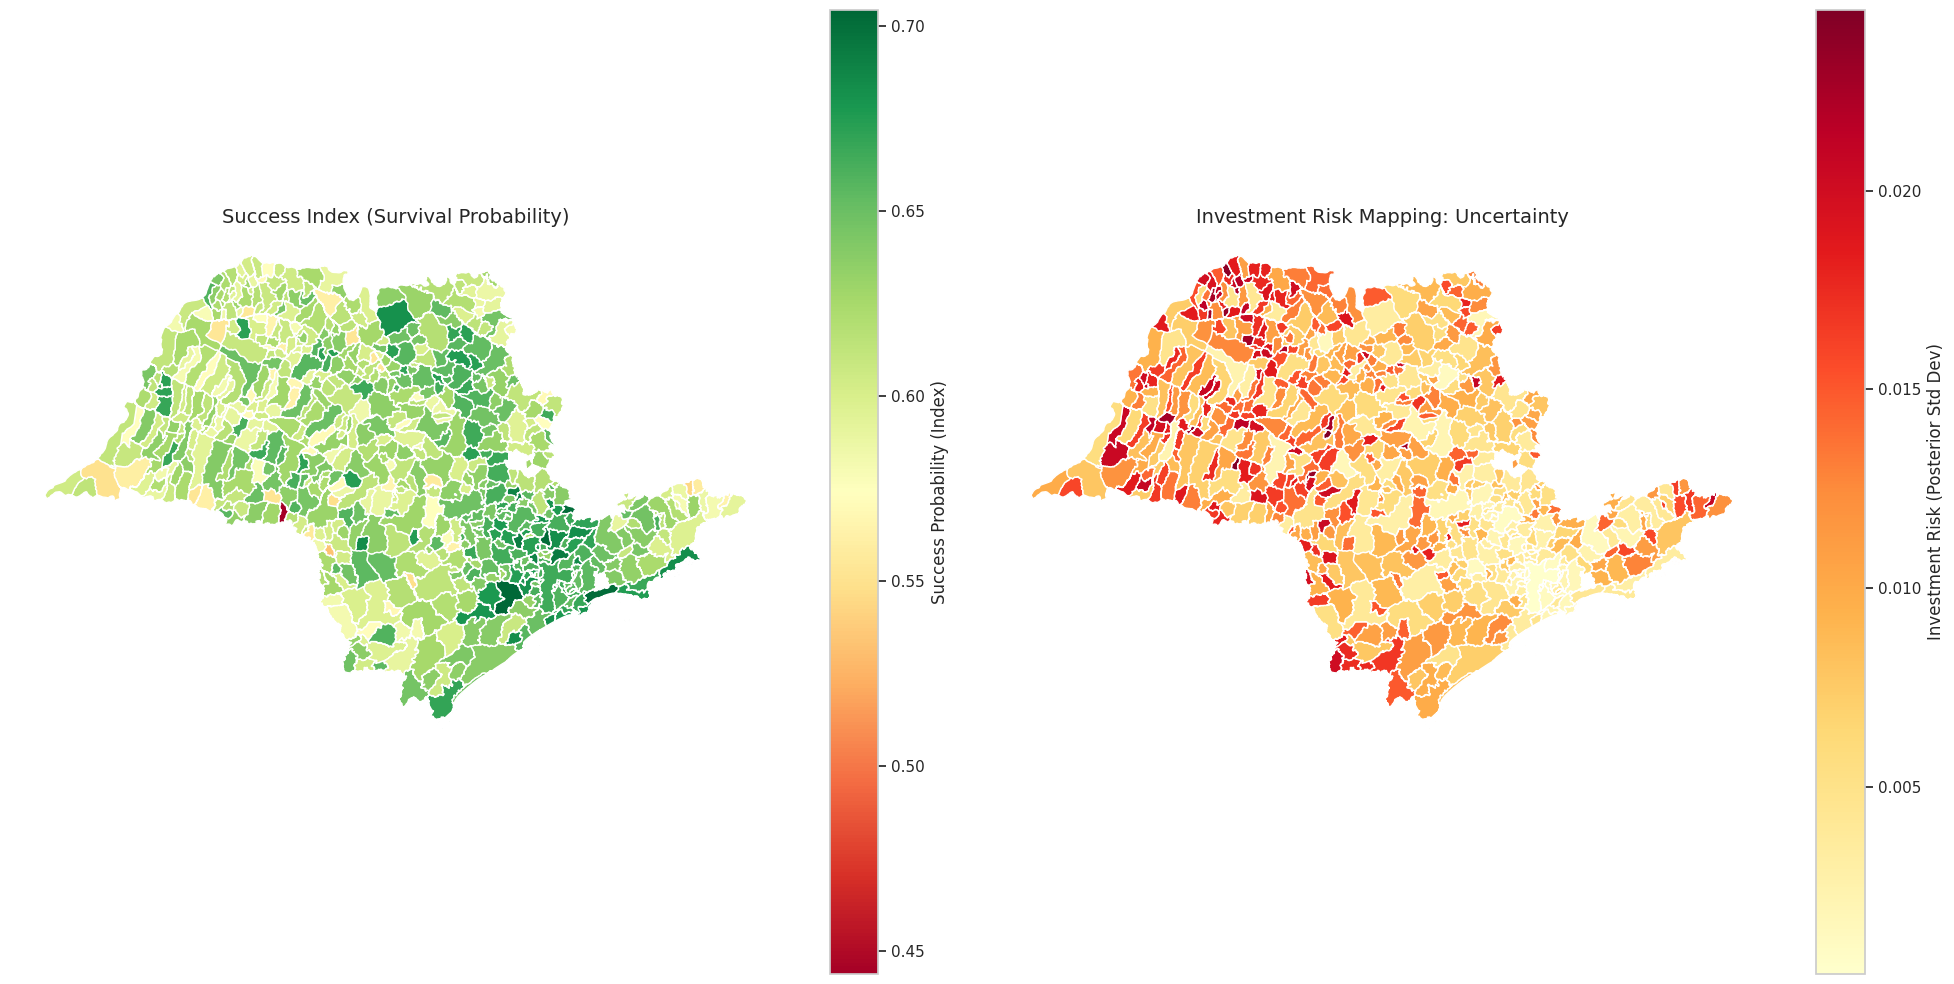

In [13]:
# --- STEP 1: CALCULATE SPATIAL KPIs ---

# Success Index: The average probability of survival (Posterior Mean)
# We aggregate across all chains and draws to find the most likely survival rate per municipality
gdf_sp['success_index'] = trace.posterior['p_success'].mean(dim=("chain", "draw")).values

# Investment Risk: The uncertainty of the estimate (Posterior Standard Deviation)
# High values indicate areas where the model predictions are less stable (higher variance)
# This is a critical metric for 'Risk-Aware' decision making in spatial econometrics
gdf_sp['investment_risk'] = trace.posterior['p_success'].std(dim=("chain", "draw")).values

# --- STEP 2: GENERATE GEOSPATIAL VISUALIZATIONS ---

# Create a two-column layout to compare Opportunity (Success) vs. Risk (Uncertainty)
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# --- Map A: Success Index (The "Opportunity" Map) ---
# We use the 'RdYlGn' (Red-Yellow-Green) colormap: Green indicates high survival probability
gdf_sp.plot(column='success_index', 
            cmap='RdYlGn', 
            legend=True, 
            legend_kwds={'label': "Success Probability (Index)"},
            ax=ax[0])
ax[0].set_title("Success Index (Survival Probability)", fontsize=14, fontweight='bold')
ax[0].axis('off') # Remove lat/long coordinates for a cleaner aesthetic

# --- Map B: Investment Risk (The "Uncertainty" Map) ---
# We use the 'YlOrRd' (Yellow-Orange-Red) colormap: Red indicates high prediction uncertainty
# Areas in deep red are where the Bayesian model suggests caution due to data volatility
gdf_sp.plot(column='investment_risk', 
            cmap='YlOrRd', 
            legend=True, 
            legend_kwds={'label': "Investment Risk (Posterior Std Dev)"},
            ax=ax[1])
ax[1].set_title("Investment Risk Mapping: Uncertainty", fontsize=14, fontweight='bold')
ax[1].axis('off')

# Final adjustments to layout
plt.tight_layout()
plt.show()

This section extracts the posterior distributions from the MCMC trace, calculates the key performance indicators (KPIs), and generates side-by-side choropleth maps.

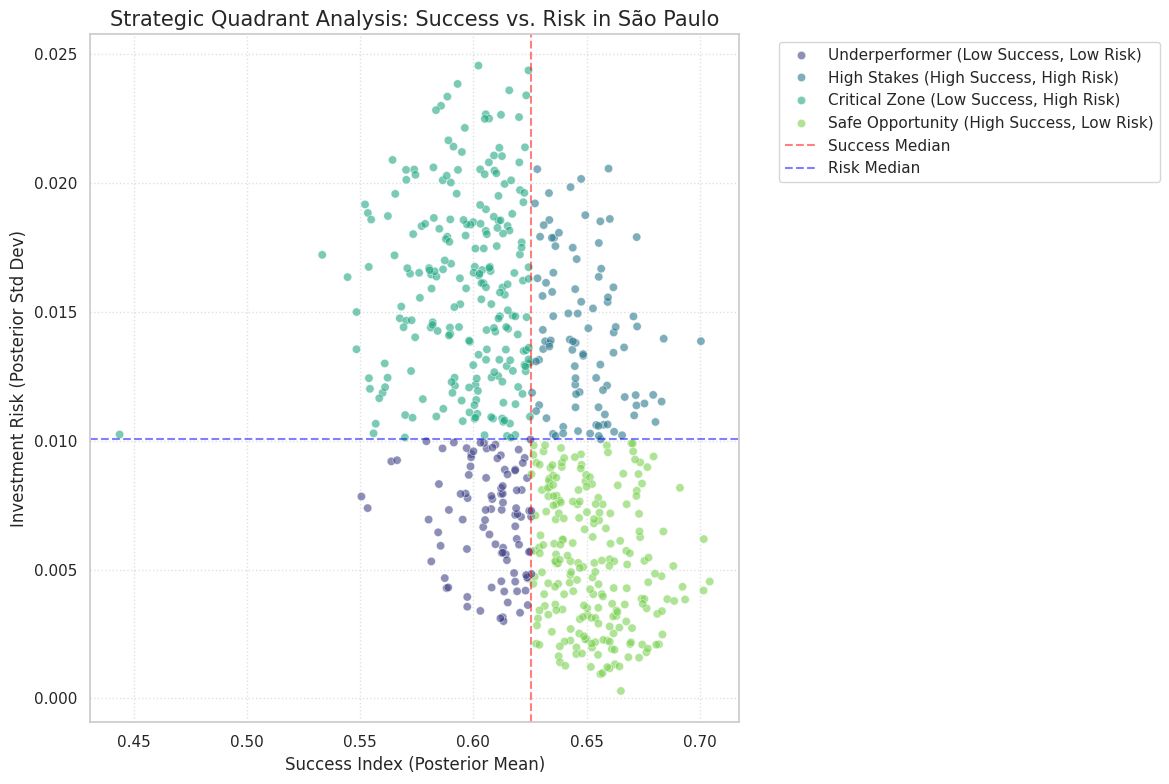

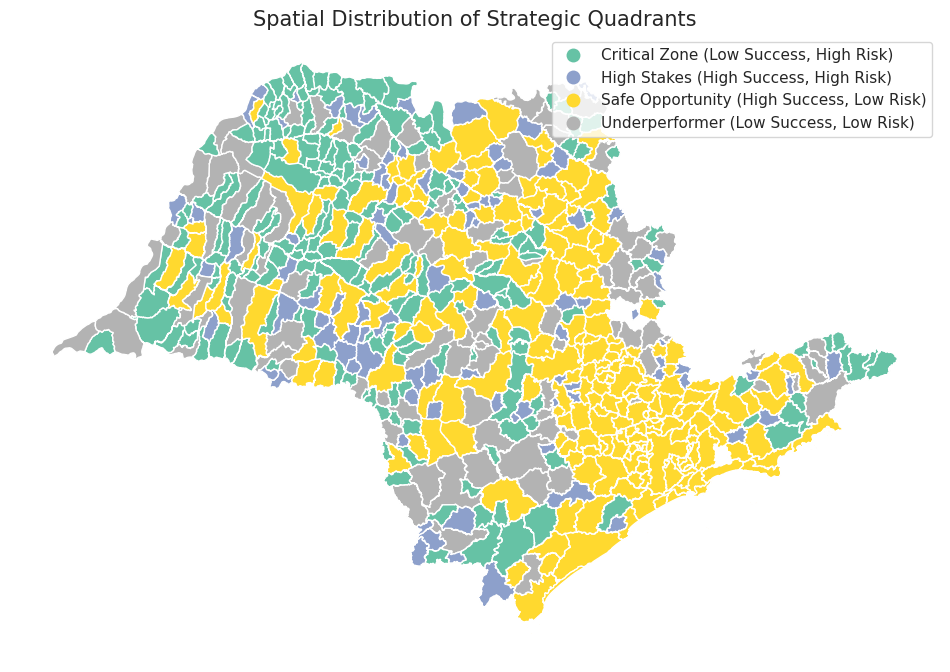

In [14]:
# --- STEP 1: DEFINE THRESHOLDS ---
# We use Medians rather than means to ensure a balanced distribution of 
# municipalities across the four quadrants, regardless of outliers.
success_median = gdf_sp['success_index'].median()
risk_median = gdf_sp['investment_risk'].median()

# --- STEP 2: QUADRANT CLASSIFICATION LOGIC ---
def classify_quadrant(row):
    # High Success + Low Risk: The 'Gold' standard for immediate investment
    if row['success_index'] >= success_median and row['investment_risk'] < risk_median:
        return 'Safe Opportunity (High Success, Low Risk)'
    
    # High Success + High Risk: High potential, but requires careful due diligence
    elif row['success_index'] >= success_median and row['investment_risk'] >= risk_median:
        return 'High Stakes (High Success, High Risk)'
    
    # Low Success + Low Risk: Consistently low performance; likely structural issues
    elif row['success_index'] < success_median and row['investment_risk'] < risk_median:
        return 'Underperformer (Low Success, Low Risk)'
    
    # Low Success + High Risk: High volatility and poor outcomes; the most vulnerable areas
    else:
        return 'Critical Zone (Low Success, High Risk)'

# Apply the classification to the GeoDataFrame
gdf_sp['quadrant'] = gdf_sp.apply(classify_quadrant, axis=1)

# --- STEP 3: STRATEGIC SCATTER PLOT ---
# This visualizes the distribution of municipalities across the decision space
plt.figure(figsize=(12, 8))
sns.scatterplot(data=gdf_sp, x='success_index', y='investment_risk', 
                hue='quadrant', palette='viridis', alpha=0.6)

# Add threshold lines to clearly delineate the four strategic zones
plt.axvline(success_median, color='red', linestyle='--', alpha=0.5, label='Success Median')
plt.axhline(risk_median, color='blue', linestyle='--', alpha=0.5, label='Risk Median')

plt.title("Strategic Quadrant Analysis: Success vs. Risk", fontsize=15, fontweight='bold')
plt.xlabel("Success Index (Posterior Mean)", fontsize=12)
plt.ylabel("Investment Risk (Posterior Std Dev)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# --- STEP 4: SPATIAL DISTRIBUTION MAP ---
# This projects the quadrants back onto the map to see geographic patterns
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf_sp.plot(column='quadrant', 
            legend=True, 
            categorical=True, 
            cmap='Set2', 
            ax=ax)

ax.set_title("Spatial Distribution of Strategic Quadrants", fontsize=15, fontweight='bold')
ax.axis('off')
plt.show()

This code block performs a Strategic Decision Framework analysis. By crossing the two dimensions of your Bayesian output (Success (Value) and Risk (Uncertainty)) we create a classification system that transforms abstract probabilities into concrete investment or policy categories.

In [15]:
def get_top_municipalities(gdf_sp, quadrant_name, top_n=10):
    """
    Filters the GeoDataFrame by quadrant and returns the top municipalities.
    - For 'High Success' quadrants: Sorts by highest success index.
    - For 'Low Success' quadrants: Sorts by lowest success index (most critical).
    """
    # Filter by quadrant
    subset = gdf_sp[gdf_sp['quadrant'] == quadrant_name].copy()
    
    # Sorting logic
    if "High Success" in quadrant_name:
        # Get the best performers
        subset = subset.sort_values(by='success_index', ascending=False)
    else:
        # Get the most vulnerable areas
        subset = subset.sort_values(by='success_index', ascending=True)
        
    return subset[['municipality_name', 'success_index', 'investment_risk']].head(top_n)

# --- EXECUTION ---

# 1. Safe Opportunity (High Success, Low Risk)
safe_opportunities = get_top_municipalities(gdf_sp, 'Safe Opportunity (High Success, Low Risk)')

# 2. High Stakes (High Success, High Risk)
high_stakes = get_top_municipalities(gdf_sp, 'High Stakes (High Success, High Risk)')

# 3. Critical Zone (Low Success, High Risk)
critical_zone = get_top_municipalities(gdf_sp, 'Critical Zone (Low Success, High Risk)')

# 4. Underperformer (Low Success, Low Risk)
underperformers = get_top_municipalities(gdf_sp, 'Underperformer (Low Success, Low Risk)')

# --- DISPLAYING RESULTS ---

print("--- TOP 10: SAFE OPPORTUNITIES ---")
print(safe_opportunities)

print("\n--- TOP 10: HIGH STAKES ---")
print(high_stakes)

print("\n--- TOP 10: CRITICAL ZONE (MOST VULNERABLE) ---")
print(critical_zone)

print("\n--- TOP 10: UNFERPERSFORMERS ---")
print(underperformers)

--- TOP 10: SAFE OPPORTUNITIES ---
    municipality_name  success_index  investment_risk
224            Ibiuna       0.704454         0.004532
283            Jarinu       0.701842         0.006179
71           Bertioga       0.701719         0.004186
318         Mairipora       0.693575         0.003837
271           Itupeva       0.692447         0.004330
215          Holambra       0.691298         0.008169
102           Cajamar       0.688743         0.003779
43     Artur Nogueira       0.688341         0.005136
44              Aruja       0.685692         0.003851
429          Piracaia       0.683958         0.006475

--- TOP 10: HIGH STAKES ---
       municipality_name  success_index  investment_risk
411           Pedra Bela       0.700552         0.013858
34                Arandu       0.684114         0.013955
264              Itariri       0.683187         0.011515
346  Monte Alegre Do Sul       0.680483         0.010725
592              Tapirai       0.679464         0.011775


In [16]:
# 1. Calculating the mean values for all predictors by quadrant
# Using THE existing 'z_predictors' list
quadrant_summary = gdf_sp.groupby('quadrant')[z_predictors].mean()

# 2. Transposing for better readability in reports
# Rows = Predictors, Columns = Strategic Quadrants
comparison_table = quadrant_summary.T
print("--- MEAN Z-SCORES BY STRATEGIC QUADRANT ---")
print(comparison_table)

# Define a logical order for the plot
quadrant_order = [
    'Safe Opportunity (High Success, Low Risk)',
    'High Stakes (High Success, High Risk)',
    'Underperformer (Low Success, Low Risk)',
    'Critical Zone (Low Success, High Risk)'
]

--- MEAN Z-SCORES BY STRATEGIC QUADRANT ---
quadrant               Critical Zone (Low Success, High Risk)  \
z_HDI_educational                                   -0.288800   
z_HDI_income                                        -0.571021   
z_HDI_longevity                                     -0.424979   
z_road_density_km_km2                               -0.386518   
z_ndvi                                              -0.059174   
z_ndbi                                               0.165004   

quadrant               High Stakes (High Success, High Risk)  \
z_HDI_educational                                  -0.286276   
z_HDI_income                                       -0.314632   
z_HDI_longevity                                    -0.285346   
z_road_density_km_km2                              -0.325946   
z_ndvi                                              0.121983   
z_ndbi                                             -0.104353   

quadrant               Safe Opportunity (High Succe

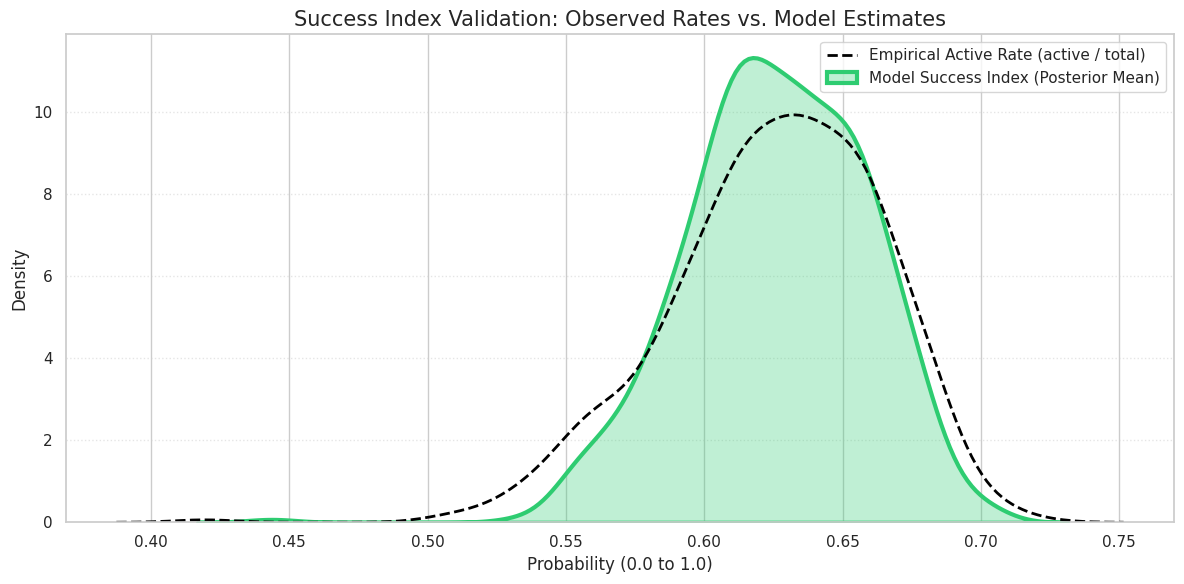

In [17]:
# --- STEP 1: CALCULATE REAL-WORLD METRICS ---
# The empirical rate is the 'raw' data: successes divided by total trials. 
# This is often noisy, especially in municipalities with very small business populations.
gdf_sp['empirical_active_rate'] = gdf_sp['active'] / gdf_sp['total']

# --- STEP 2: EXTRACT MODEL PREDICTIONS ---
# We aggregate the high-dimensional posterior (chains x draws x municipalities) 
# into a single representative vector (Success Index) for comparison.
success_index_mean = trace.posterior['p_success'].mean(dim=("chain", "draw")).values

# --- STEP 3: GENERATE THE VALIDATION PLOT ---
# Kernel Density Estimation (KDE) is used here to visualize the 'shape' of the data.
plt.figure(figsize=(12, 6))

# Observed Data Distribution: The 'Truth'
# We use a dashed black line to represent the raw, un-modeled data distribution.
sns.kdeplot(gdf_sp['empirical_active_rate'], 
            label="Empirical Active Rate (active / total)", 
            color="black", lw=2, linestyle="--")

# Model Estimate Distribution: The 'Learned' Pattern
# We use a solid green fill to show how the Bayesian model interprets that data.
# Note: The model's curve is usually smoother because the ICAR spatial effect 
# 'borrows strength' from neighbors to correct for outliers.
sns.kdeplot(success_index_mean, 
            label="Model Success Index (Posterior Mean)", 
            color="#2ecc71", fill=True, alpha=0.3, lw=3)

# Formatting for professional research publication
plt.title("Success Index Validation: Observed Rates vs. Model Estimates", fontsize=15, fontweight='bold')
plt.xlabel("Probability (0.0 to 1.0)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

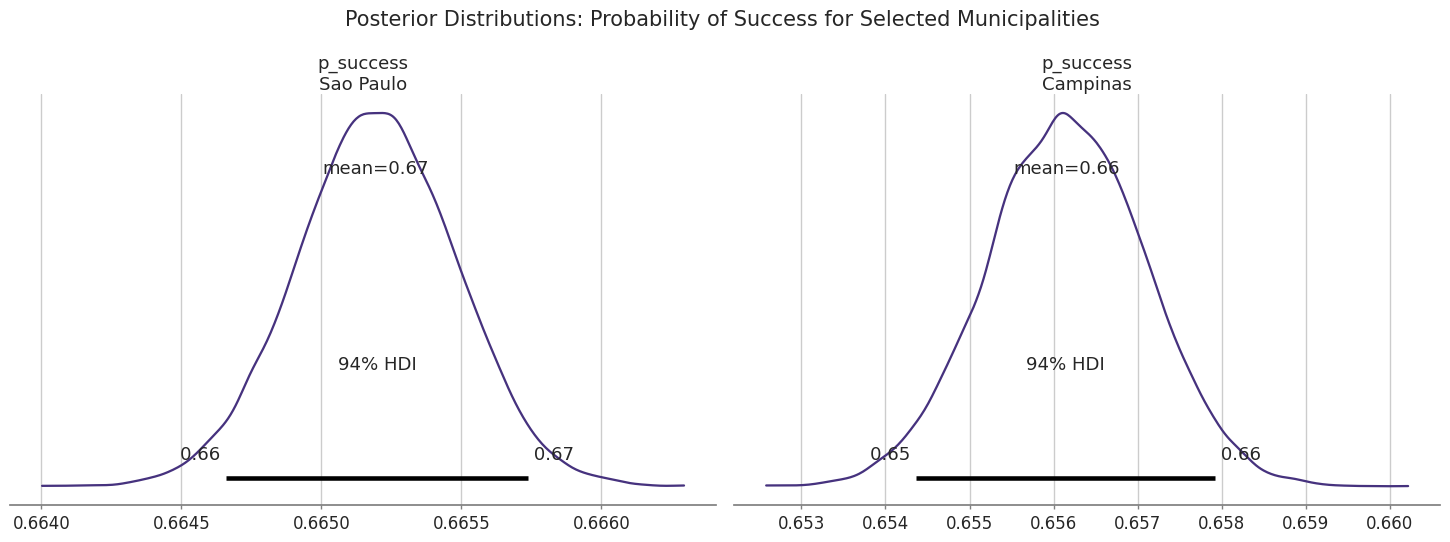

In [ ]:
# 1. Identify the column with municipality
name_column = 'municipality_name' 
municipality_names = gdf_sp[name_column].values

# 2. Map the names to the trace coordinates
# This replaces indices [0, 1, 2...] with actual names globally in the trace
trace.posterior = trace.posterior.assign_coords(p_success_dim_0=municipality_names)

# 3. Select the names of the municipalities you want to see
target_municipalities = ['Sao Paulo', 'Campinas'] # Replace with city name

# 4. Plot using the names
az.plot_posterior(trace, 
                  var_names=['p_success'],
                  coords={'p_success_dim_0': target_municipalities},
                  hdi_prob=0.94,
                  textsize=12)

plt.suptitle("Posterior Distributions: Probability of Success for Selected Municipalities", fontsize=15)
plt.tight_layout()
plt.show()


In [ ]:
# Target: Empirical rate (0 to 1)
y_rate = gdf_sp['active'] / gdf_sp['total']

# Add constant for intercept
X_matrix = gdf_sp[z_predictors].values.astype('float64')
X_ols = sm.add_constant(X_matrix) 

# Fit OLS
ols_model = sm.OLS(y_rate, X_ols).fit()

print("--- OLS REGRESSION SUMMARY ---")
print(ols_model.summary())

--- OLS REGRESSION SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     24.90
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.39e-26
Time:                        23:34:44   Log-Likelihood:                 1246.3
No. Observations:                 642   AIC:                            -2479.
Df Residuals:                     635   BIC:                            -2447.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6252

In [20]:
# --- 1. REDEFINE DATA ARRAYS ---
n_obs = gdf_sp['total'].values.astype('int32')
y_obs_data = gdf_sp['active'].values.astype('int32')
X_matrix = gdf_sp[z_predictors].values.astype('float64')

# --- 2. BAYESIAN LINEAR REGRESSION ---
print(f"\n Creating sampling...")

with pm.Model() as bayesian_linear_model:
    # Priors
    # Intercept: Baseline success probability across the state
    # Global Intercept: Represents the baseline success rate when predictors are zero
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    # Fixed Effects: Impact of road density, vegetation, and income on survival
    # Fixed Effects: Coefficients for scaled predictors (Standardized impact)
    beta = pm.Normal("beta", mu=0, sigma=1, shape=X_matrix.shape[1])

    # Link Function
    logit_p = alpha + pm.math.dot(X_matrix, beta)
    p_success = pm.Deterministic("success_index", pm.math.invlogit(logit_p))

    # Likelihood
    y = pm.Binomial("y", n=n_obs, p=p_success, observed=y_obs_data)

    # PARALLEL SAMPLING CONFIG:
    # chains: total number of independent "paths"
    # High-Performance Sampling: Using JAX/NumPyro for parallel MCMC execution
    trace_linear = pm_jax.sample_numpyro_nuts(  # if you don't want to use a GPU change this for "pm.sample"
        draws=6000, 
        tune=2000, 
        chains=4,           # Number of chains        
        target_accept=0.95,  # include the in other line the argument "cores = X" that you would like to use 
        progressbar=True
    )

print("\n Sampling complete!")



 🚀 Creating sampling...


sample: 100%|██████████| 8000/8000 [00:55<00:00, 145.15it/s, 15 steps of size 7.04e-02. acc. prob=0.94]



 ✅ Sampling complete!


 📊 Bayesian Linear Baseline Results:
          mean     sd  hdi_3%  hdi_97%  r_hat
alpha    0.549  0.001   0.547    0.552    1.0
beta[0] -0.004  0.001  -0.006   -0.001    1.0
beta[1]  0.015  0.001   0.014    0.017    1.0
beta[2]  0.006  0.001   0.003    0.008    1.0
beta[3]  0.037  0.001   0.035    0.038    1.0
beta[4]  0.011  0.002   0.008    0.015    1.0
beta[5] -0.038  0.002  -0.042   -0.035    1.0


<Figure size 1000x600 with 0 Axes>

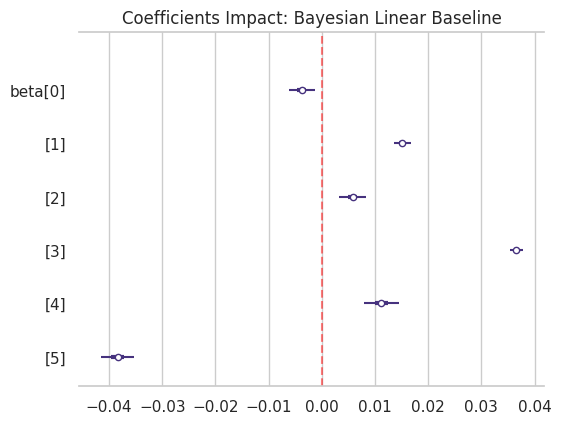


 🐍 Checking chain overlap (Caterpillar plots):


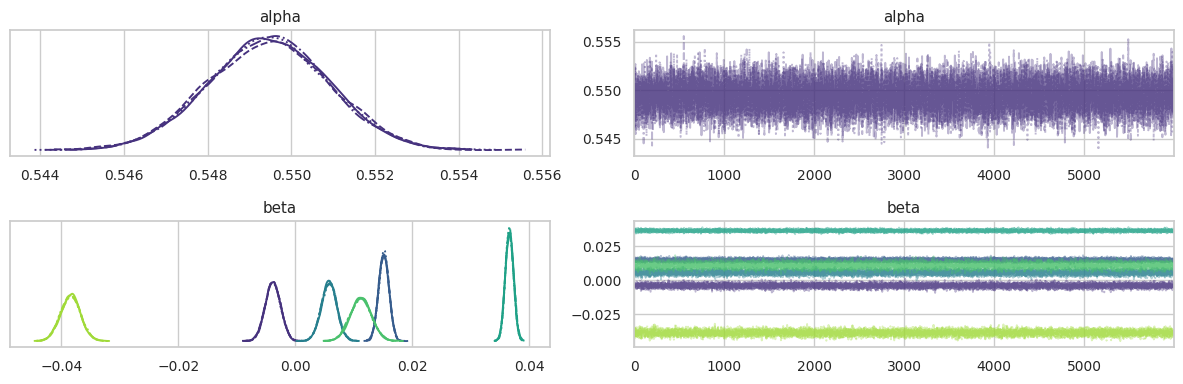


 ✅ SUCCESS: Model converged beautifully (Max R-hat: 1.000)


In [ ]:
# --- 1. MODEL SUMMARY ---
# This shows the mean effect of each variable and the R-hat convergence diagnostic.
print(" 📊 Bayesian Linear Baseline Results:")
baseline_summary = az.summary(trace_linear, var_names=["alpha", "beta"], round_to=3)
print(baseline_summary[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]])

# --- 2. FOREST PLOT ---
# Visualizes the predictors.
plt.figure(figsize=(10, 6))
az.plot_forest(trace_linear, var_names=['beta'], combined=True, hdi_prob=0.94)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.title("Coefficients Impact: Bayesian Linear Baseline")
plt.show()

# --- 3. CONVERGENCE CHECK (Trace Plot) ---
# Each colorful "furry caterpillar" should overlap. If they do, the model is stable.
print("\n 🐍 Checking chain overlap (Caterpillar plots):")
az.plot_trace(trace_linear, var_names=["alpha", "beta"])
plt.tight_layout()
plt.show()

# --- 4. SUCCESS CHECK ---
max_rhat = baseline_summary["r_hat"].max()
if max_rhat < 1.05:
    print(f"\n ✅ SUCCESS: Model converged beautifully (Max R-hat: {max_rhat:.3f})")
else:
    print(f"\n ⚠️ WARNING: Some chains did not converge well (Max R-hat: {max_rhat:.3f})")

 📓 Calculating Log-Likelihood for Spatial Model...


Output()

Output()

 📓 Calculating Log-Likelihood for Linear Model...



 📊 Calculating Model Comparison...


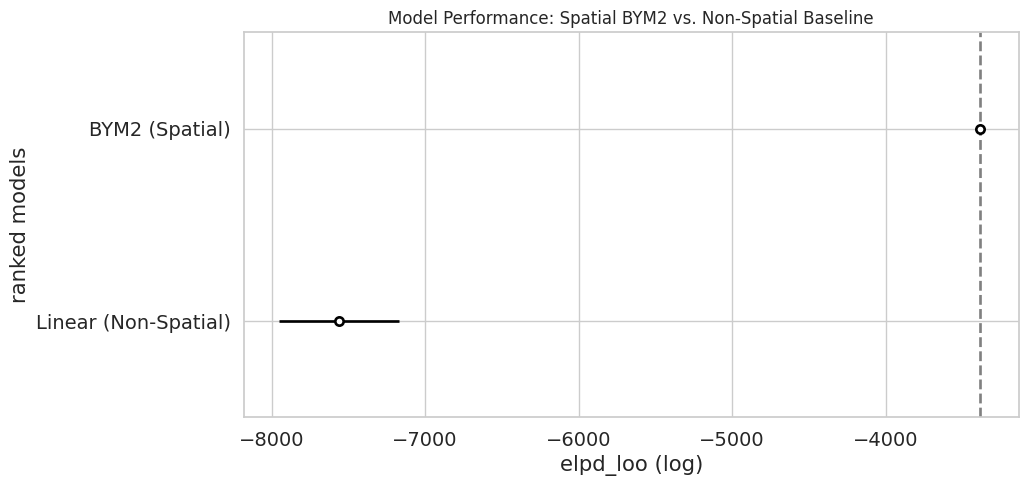

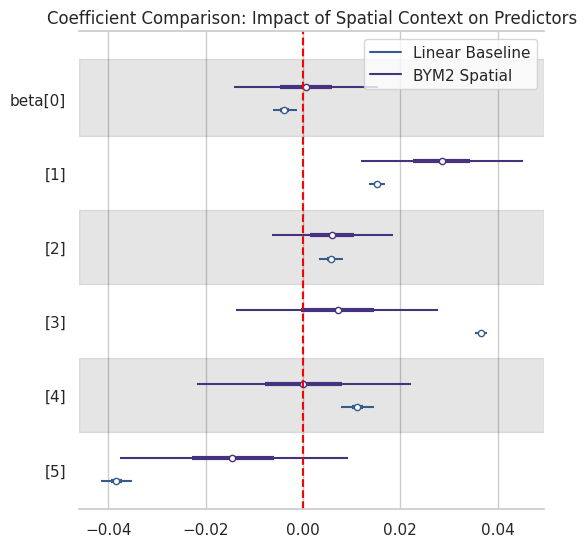


--- BAYESIAN COMPARISON TABLE ---
                      rank     elpd_loo       p_loo    elpd_diff  weight
BYM2 (Spatial)           0 -3388.311365  526.645917     0.000000     1.0
Linear (Non-Spatial)     1 -7560.901203  170.082228  4172.589838     0.0


In [22]:
# --- STEP 1: GENERATE LOG-LIKELIHOOD FOR BOTH MODELS ---
# This is required for LOO/WAIC model comparison
print(" Calculating Log-Likelihood for Spatial Model...")
with success_model:
    pm.compute_log_likelihood(trace)

print(" Calculating Log-Likelihood for Linear Model...")
with bayesian_linear_model:
    pm.compute_log_likelihood(trace_linear)

# --- STEP 2: MODEL COMPARISON (WAIC / LOO) ---
print("\n Calculating Model Comparison...")
model_comparison = az.compare({
    "BYM2 (Spatial)": trace, 
    "Linear (Non-Spatial)": trace_linear
})

# --- STEP 3: GENERATE PLOTS ---

# Plot A: LOO Comparison
# Larger (more right) is better. The 'triangle' is the predictive power.
az.plot_compare(model_comparison, figsize=(10, 5))
plt.title("Model Performance: Spatial BYM2 vs. Non-Spatial Baseline")
plt.show()

# Plot B: Forest Plot (Coefficient Comparison)
# This shows how beta values shift when space is taken into account.
az.plot_forest([trace, trace_linear], 
               model_names=["BYM2 Spatial", "Linear Baseline"],
               var_names=["beta"], 
               combined=True, 
               hdi_prob=0.94)
plt.axvline(0, color='red', linestyle='--')
plt.title("Coefficient Comparison: Impact of Spatial Context on Predictors")
plt.show()

# --- STEP 4: PRINT FINAL TABLE ---
print("\n--- BAYESIAN COMPARISON TABLE ---")
print(model_comparison[["rank", "elpd_loo", "p_loo", "elpd_diff", "weight"]])


Sampling: [y_obs]


Output()

✨ Generating posterior predictive samples...


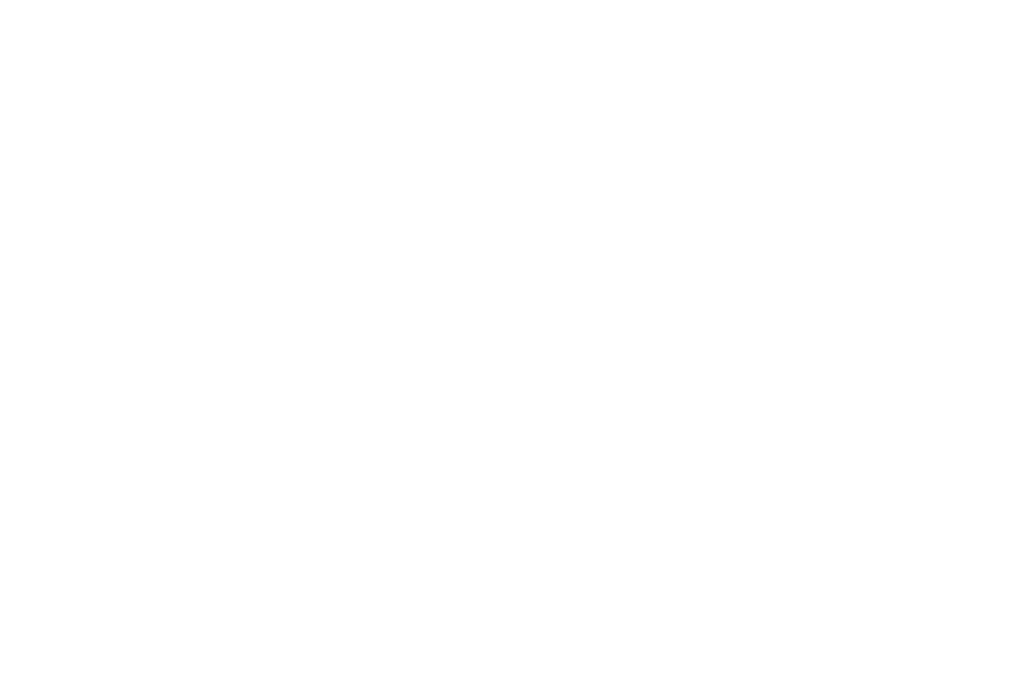


🔍 Checking for Spatial Bias (Autocorrelation in Residuals):
   → OLS Residuals Moran's I: 0.119 (p=0.0010)
   → Spatial Model Moran's I: -0.049 (p=0.0270)


In [ ]:
# --- 1. RUN OLS (FREQUENTIST BASELINE) ---
X_ols = sm.add_constant(X_matrix)
# Predict probability (y/n) since y_obs is counts
ols_model = sm.OLS(y_obs_data / n_obs, X_ols)
ols_result = ols_model.fit()

# --- 2. EXTRACT OLS DATA FOR PLOTTING ---
ols_betas = ols_result.params[1:]
ols_ci = np.array(ols_result.conf_int())[1:]

# --- 3. GENERATE POSTERIOR PREDICTIONS ---
# We need to explicitly simulate y_obs based on the sampled posterior
with success_model:
    print("Generating posterior predictive samples...")
    ppc = pm.sample_posterior_predictive(trace)
    trace.extend(ppc)

# --- 4. PLOT COEFFICIENT COMPARISON ---
fig, ax = plt.subplots(figsize=(12, 8))

# Bayesian Forest plots
az.plot_forest([trace, trace_linear], 
               model_names=["Spatial (BYM2)", "Linear (Bayesian)"],
               var_names=["beta"], 
               combined=True, 
               hdi_prob=0.94,
               colors=['steelblue', 'forestgreen'],
               ax=ax)

# Manually add OLS to the same plot (offset slightly for visibility)
y_positions = np.arange(len(ols_betas))
ax.errorbar(ols_betas[::-1], y_positions - 0.2, 
             xerr=[(ols_betas - ols_ci[:, 0])[::-1], (ols_ci[:, 1] - ols_betas)[::-1]],
             fmt='o', color='red', label='OLS (Frequentist)', markersize=8)

# Legend configuration
legend_elements = [
    Line2D([0], [0], color='steelblue', lw=4, label='Spatial (BYM2)'),
    Line2D([0], [0], color='forestgreen', lw=4, label='Linear (Bayesian)'),
    Line2D([0], [0], color='red', marker='o', linestyle='none', markersize=8, label='OLS (Frequentist)')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, fontsize=11)

ax.axvline(0, color='black', linestyle='--', alpha=0.3)
ax.set_title("Coefficient Comparison: OLS vs. Bayesian Models", fontsize=14)
plt.show()

# --- 5. MORAN'S I RESIDUAL TEST ---
print("\n Checking for Spatial Bias (Autocorrelation in Residuals):")

# OLS Residuals
mi_ols = Moran(ols_result.resid, w)

# Spatial Model Residuals
y_pred_mean = trace.posterior_predictive['y_obs'].mean(dim=['chain', 'draw']).values
spatial_resids = (y_obs_data / n_obs) - (y_pred_mean / n_obs)
mi_spatial = Moran(spatial_resids, w)

print(f"   → OLS Residuals Moran's I: {mi_ols.I:.3f} (p={mi_ols.p_sim:.4f})")
print(f"   → Spatial Model Moran's I: {mi_spatial.I:.3f} (p={mi_spatial.p_sim:.4f})")

## 4 - Next Steps & Scaling the Framework

Following the successful pilot implementation in São Paulo, the next phases of this project will transition from regional validation to a **scalable national analytical framework** capable of evaluating market viability across Brazil.

### National Implementation and Scaling
The Bayesian spatial model will be expanded to cover all **5,570 Brazilian municipalities**, enabling the creation of a nationwide spatial assessment of economic resilience and market-entry viability. This expansion will permit a regional analytical approach into a **national strategic decision-support** for entrepreneurs, policymakers, and development agencies.

### Cross-Regional Validation
The incorporation of national-scale data will significantly increase the diversity of spatial contexts represented in the model. This expanded dataset will allow systematic validation across heterogeneous environments, including comparisons between **high-density metropolitan regions and low-density rural municipalities**. Such cross-regional evaluation will improve model robustness and ensure consistent statistical performance across Brazil’s diverse economic landscapes.

### Hierarchical and Spatial Modeling
To capture Brazil’s complex geographic and administrative structure, the model will employ a **nested hierarchical spatial framework**. 

- **Spatial Random Effect**:  
  $\phi_i$ (ICAR) will capture **neighbor-to-neighbor spatial spillovers** and local spatial autocorrelation between municipalities.

- **Hierarchical Random Effect**:  
  $u_j$ will account for broader **state- and region-level variation**, reflecting Brazil’s **27 states and 5 macro-regions**.

This structure enables the model to simultaneously capture **local spatial dependencies and higher-level institutional or economic differences**.

### Sectoral Diversification
Beyond aggregated business data, the framework will be extended to incorporate **sector-specific analysis** (e.g., retail, manufacturing, healthcare, and services). Different economic sectors exhibit distinct spatial dynamics and location requirements—such as proximity to consumers, logistics infrastructure, or specialized labor markets. Modeling sectors separately will enable **more precise and context-sensitive market-entry predictions**.

### Empirical Execution with High-Performance Computing
Scaling the model to a national level significantly increases computational demands, particularly given the binomial likelihood structure:

$$
Failed_{i,s} \sim \text{Binomial}
$$

across municipalities and sectors. To ensure efficient Bayesian inference, the analysis will be executed using **high-performance computing resources on the Anvil GPU cluster** to enable parallelized estimation and faster convergence.

### Validation, Visualization, and Open Science

**Model Comparison**

The integrated model will be evaluated against a baseline model relying solely on IBGE indicators. Predictive performance will be assessed using:

- **WAIC (Widely Applicable Information Criterion)**
- **LOO-CV (Leave-One-Out Cross-Validation)**

to confirm the predictive advantage of the spatially integrated framework.

**Resilience Mapping**

Model outputs will be translated into intuitive spatial products, including:

- **Posterior Mean Maps** — representing estimated survival probability (economic resilience)
- **Posterior Uncertainty Maps** — indicating investment risk and model confidence

**Open Science**

To ensure transparency and reproducibility, the complete analytical workflow, including data processing, model specification, and visualization, will be published as a **Jupyter Notebook on the i-Guide Platform**, supporting open-science practices and enabling reuse by researchers, policymakers, and development practitioners.

## 5 - Impact and Future Directions

### Broader Impact

The proposed Spatial AI framework has the potential to significantly improve how entrepreneurs, policymakers, and development institutions identify viable locations for economic activity. By integrating socioeconomic data, infrastructure indicators, and remote sensing signals within a Bayesian spatial modeling framework, the project provides a systematic approach to understanding how geographic context shapes market viability.

In many developing regions, decision-making about business location and investment is often constrained by incomplete economic statistics, limited spatial analysis capacity, and high uncertainty regarding local demand conditions. The framework developed in this project addresses these challenges by combining traditional data sources with geospatial information derived from OpenStreetMap and satellite imagery. This integration allows the model to infer patterns of economic activity, accessibility, and spatial spillovers even in environments where conventional economic data may be sparse or outdated.

As a result, this framework can serve as a spatial decision-support tool that helps reduce uncertainty in market-entry decisions, improves the allocation of entrepreneurial capital, and supports more balanced regional development. In addition to its relevance for private-sector decision-making, the framework can also assist public agencies in identifying underserved areas, prioritizing infrastructure investments, and designing policies aimed at fostering local economic resilience.

### Applicability to Other Developing Regions

Although the initial implementation focuses on Brazil, the methodological design of the framework is intentionally data-flexible and geographically transferable. Many developing countries face similar challenges, including strong regional disparities, incomplete economic statistics, and rapid spatial transformation. Because the model integrates globally available datasets—such as satellite imagery and OpenStreetMap infrastructure data—it can be adapted to other national contexts with relatively limited additional data collection.

This approach makes the framework particularly relevant for countries in Latin America, Sub-Saharan Africa, and South and Southeast Asia, where economic activity is often unevenly distributed and spatial information is essential for identifying emerging market opportunities. By combining spatial statistics with scalable geospatial data sources, the framework offers a pathway toward evidence-based spatial economic planning in data-constrained environments.

### Future Research Directions

Several research directions will extend and strengthen the framework in future phases of the project:

**1. Global Model Transferability**  
Future work can explore applying the model to additional countries with diverse spatial and economic structures. Comparative implementations across different regions will allow evaluation of how well the framework generalizes across varying institutional and geographic contexts.

**2. Temporal and Dynamic Modeling**  
Subsequent research can incorporate time-series data to model economic dynamics and spatial change over time. This extension will allow the framework to detect emerging growth corridors, urban expansion patterns, and evolving market opportunities.

**3. Enhanced Remote Sensing Integration**  
Future versions of the model can expand the use of satellite-derived indicators from platforms such as Sentinel-2 and other Earth observation systems. These data can provide richer proxies for urban growth, built-environment intensity, and land-use change, further improving predictive accuracy in regions where economic statistics are limited.

**4. Sector-Specific Spatial Modeling**  
Building on the sectoral diversification already introduced in the framework, future work can develop sector-specific spatial models that capture the distinct location requirements of different industries, enabling more targeted market-entry recommendations.

**5. Entrepreneurial Knowledge and Experience Integration**  
An important extension of the framework can be the incorporation of entrepreneurial behavioral factors (e.g., personal knowledge, experience, and local familiarity in shaping market-entry decisions). While the current model focuses primarily on spatial and structural determinants of market viability, future research can explore how individual-level characteristics, such as prior entrepreneurial experience, industry expertise, and local network knowledge, interact with geographic opportunity structures. Integrating these elements may involve linking survey-based data, entrepreneurial registries, or behavioral indicators with the spatial model, enabling a more comprehensive understanding of how human capital and spatial opportunity jointly influence entrepreneurial success.

---

Together, these future developments can extend the project from a national analytical framework into a globally applicable Spatial AI system for economic opportunity mapping, helping to reduce uncertainty in market-entry decisions and promote more inclusive regional development.